## 3.2 Reach-avoid flight

**(a)**

We want to find $\mathbf{u}^* = \arg\min_{\mathbf{u}} \mathbf{p}^\top f(\mathbf{x}, \mathbf{u})$ where $\mathbf{p} = \nabla_{\mathbf{x}} V$ and the reduced dynamics are

$$
f(\mathbf{x}, \mathbf{u}) = \begin{bmatrix} v_y \\ \frac{(T_1+T_2)\cos\phi - C_D^v v_y}{m} - g \\ \omega \\ \frac{(T_2-T_1)\ell - C_D^\phi \omega}{I_{yy}} \end{bmatrix}.
$$

Expanding $\mathbf{p}^\top f$, only the terms involving $T_1, T_2$ matter for the minimization:

$$
\mathbf{p}^\top f = \cdots + T_1\!\left(\frac{p_2 \cos\phi}{m} - \frac{p_4 \ell}{I_{yy}}\right) + T_2\!\left(\frac{p_2 \cos\phi}{m} + \frac{p_4 \ell}{I_{yy}}\right).
$$

This is linear in $T_1$ and $T_2$ (which are decoupled), so the minimum over $[0, T_{\max}]$ is attained at the extremes:

$$
T_1^* = \begin{cases} T_{\max} & \text{if } \frac{p_2 \cos\phi}{m} - \frac{p_4 \ell}{I_{yy}} < 0, \\ 0 & \text{otherwise,} \end{cases}
\qquad
T_2^* = \begin{cases} T_{\max} & \text{if } \frac{p_2 \cos\phi}{m} + \frac{p_4 \ell}{I_{yy}} < 0, \\ 0 & \text{otherwise.} \end{cases}
$$

In [1]:
import jax.numpy as jnp
def optimal_control(self, state, grad_value):
    y, v_y, phi, omega = state
    p1, p2, p3, p4 = grad_value

    coeff_T1 = p2 * jnp.cos(phi) / self.m - p4 * self.l / self.Iyy
    coeff_T2 = p2 * jnp.cos(phi) / self.m + p4 * self.l / self.Iyy

    T_1 = jnp.where(coeff_T1 < 0, self.max_thrust_per_prop, 0.0)
    T_2 = jnp.where(coeff_T2 < 0, self.max_thrust_per_prop, 0.0)

    return jnp.array([T_1, T_2])

**(b)**

The target set is $\mathcal{T} = [3,7] \times [-1,1] \times [-\pi/12, \pi/12] \times [-1,1]$. We need $h(\mathbf{x}) \le 0 \iff \mathbf{x} \in \mathcal{T}$.

For each dimension, $x \in [a,b] \iff \max(a - x,\; x - b) \le 0$. Taking the pointwise maximum over all dimensions:

$$
h(\mathbf{x}) = \max\!\left\{\max(3-y,\; y-7),\; \max(-1-v_y,\; v_y-1),\; \max\!\left(-\tfrac{\pi}{12}-\phi,\; \phi-\tfrac{\pi}{12}\right),\; \max(-1-\omega,\; \omega-1) \right\}.
$$

In [2]:
def target_set(state):
    y, v_y, phi, omega = state
    return jnp.max(jnp.array([
        jnp.maximum(3.0 - y, y - 7.0),
        jnp.maximum(-1.0 - v_y, v_y - 1.0),
        jnp.maximum(-jnp.pi / 12.0 - phi, phi - jnp.pi / 12.0),
        jnp.maximum(-1.0 - omega, omega - 1.0),
    ]))

**(c)**

The operational envelope is $\mathcal{E} = [1,9] \times [-6,6] \times [-\infty,\infty] \times [-8,8]$. Similarly to part (b):

$$
e(\mathbf{x}) = \max\!\left\{\max(1-y,\; y-9),\; \max(-6-v_y,\; v_y-6),\; \max(-8-\omega,\; \omega-8) \right\}.
$$

$e$ does not contain $\phi$ as there is no constraint on $\phi$.

In [3]:
def envelope_set(state):
    y, v_y, phi, omega = state
    return jnp.max(jnp.array([
        jnp.maximum(1.0 - y, y - 9.0),
        jnp.maximum(-6.0 - v_y, v_y - 6.0),
        jnp.maximum(-8.0 - omega, omega - 8.0),
    ]))

**(d)**

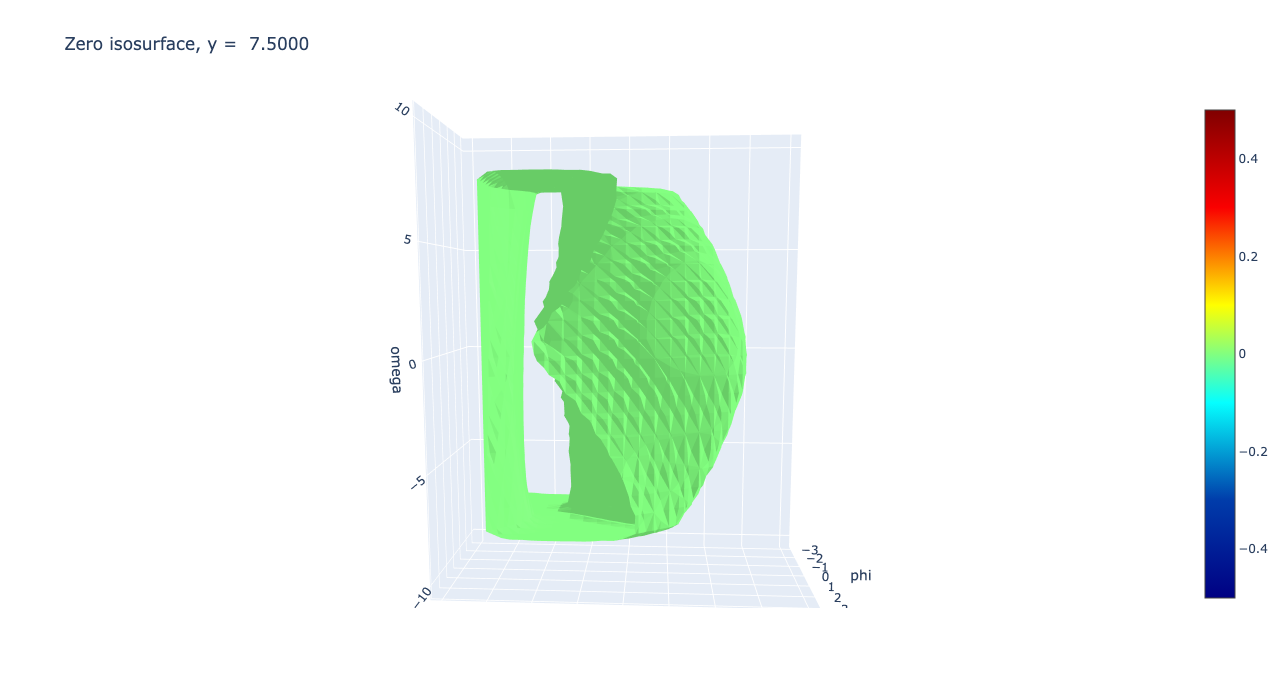

In [4]:
from IPython.display import Image, display
display(Image(filename='isosurface.png', width=700))

At $y = 7.5$ we are near the top of the envelope ($y \le 9$), so the enclosed region shows which $(v_y, \phi, \omega)$ states can still reach the target without leaving $\mathcal{E}$.

The diagonal tilt in $(\phi, \omega)$ comes from the fact that if $\phi$ and $\omega$ have opposite signs (say $\phi > 0, \omega < 0$), the pitch rate is already correcting the tilt, so recovery is easier. But if they have the same sign, the drone keeps rotating the wrong way and since thrust is bounded ($T_1, T_2 \in [0, T_{\max}]$) we can't reverse the rotation fast enough before leaving the envelope. Those corners get excluded from the recoverable set, which is why the surface stretches along the opposite-sign diagonal.

The surface is also not symmetric in $v_y$ because at $y = 7.5$ an upward velocity only has $1.5$m before hitting the ceiling at $y = 9$, while a downward velocity has $6.5$m of room before the floor at $y = 1$. So the region is narrower for large positive $v_y$.

**(e)**

With DP/HJB we get a globally optimal policy over the whole state space, and at runtime it's just a table lookup so it's basically free to evaluate online. We also get the backward reachable set for free, which tells us exactly which states are recoverable. The main issue is the curse of dimensionality — the grid scales as $O(N^d)$ so both memory and offline compute blow up fast. That's why we had to drop from 6D to 4D here. Also, since the Hamiltonian is linear in the controls, the policy ends up being bang-bang ($T_1, T_2 \in \{0, T_{\max}\}$), which is optimal in theory but in practice means aggressive switching that's bad for actuators. And if we want to add obstacles later, we have to redo the whole computation.

MPC doesn't have the dimensionality problem since it just solves a local optimization at each step instead of gridding the state space. It's also easy to add new constraints or obstacles on the fly, and the optimization naturally gives smoother controls. The tradeoff is that it's only locally optimal, so it can fail from hard initial conditions where DP would have found a way out. Plus we need to solve an optimization at every timestep, which can be tight for something as fast as a self-righting maneuver.